# Image-Level EDA
The bias matching process applied in the previous metadata EDA notebook tells us that the bias matching can be applied to reduce the bias in the dataset. However, it is also important to perform an image-level EDA to understand the distribution of images and their characteristics.

Crucially, this notebook combines multiple per source manifests in `data/interim` (produced by `scripts/build_manifest.py`) into a single combined manifest (`data/interim/manifest_final.parquet`) with paths pointing to the final, model-ready image folders under `data/processed/`, allowing for an overall image analysis. Train/val/test splits are allocated here.

The pipeline this notebook follows is as follows:


```text
per-source manifests (data/interim/*.parquet)
        |
        v
combine_manifests()          -- into one DataFrame standardized to canonical columns
        |
        v
drop is_corrupt rows          -- ignored going forward
        |
        v
assign_group_ids()             -- cross-source near-duplicate clustering (banded LSH)
        |
        v
apply_matching()                -- bias-match real GenImage images (size + JPEG QF)
        |
        v
assign_full_splits()           -- group-aware GenImage split + fixed lookup for
                                   coco / ntire / raise
        |
        v
assert_no_leakage()             -- hard stop if any group/hash spans two splits
        |
        v
save data/interim/manifest_final.parquet
        |
        v
build_processed_dataset()      -- resize + re-encode every surviving image
        |
        v
data/processed/<split>/<ai|human>/<sha256>.jpg
        +
data/processed/manifest.parquet

### 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

## Standard Libraries
from pathlib import Path
import numpy as np
import pandas as pd
import yaml

## Project module imports
from ai_detector.data.selection import(
    SubsetConfig, combine_manifests, assign_group_ids, apply_matching, assign_full_splits, 
    normalize_columns, shortcut_probe)
from ai_detector.data.manifest import(assert_no_leakage, LeakageError)
from ai_detector.data import viz
from ai_detector.preprocessing.image_ops import PreprocessConfig, build_processed_dataset
from ai_detector.data.integrity import near_duplicate_pairs

## Path setup
PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "data"
INTERIM = DATA / "interim"
PROCESSED = DATA / "processed"
RAW = DATA / "raw"
CONFIG_PATH = PROJECT_ROOT / "configs" / "data" / "subset_v1.yaml"

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

## Preprocessing and data splitting will draw from a yaml file in configs/data
cfg = SubsetConfig.from_yaml(CONFIG_PATH)
raw_cfg = yaml.safe_load(CONFIG_PATH.read_text())
preprocess_cfg = PreprocessConfig.from_yaml_dict(raw_cfg.get("preprocessing", {}))

print(cfg)
print(preprocess_cfg)

SubsetConfig(name='subset_v1', seed=42, real_generator_token='nature', train_generators=['stable_diffusion_v_1_4', 'stable_diffusion_v_1_5', 'glide', 'adm', 'vqdm'], ood_generators=['midjourney', 'wukong', 'biggan'], min_side=450, max_side=550, jpeg_qf=98, jpeg_qf_tolerance=2, val_fraction=0.1, test_in_dist_fraction=0.1, pilot_n_per_stratum=60)
PreprocessConfig(image_size=512, jpeg_qf=98, resample=<Resampling.LANCZOS: 1>)


### 1. Load and combine per-source manifests
Draws from the per-source manifests stored in `data/interim`

In [2]:
manifest_paths = sorted(INTERIM.glob("manifest_*.parquet"))
print(f"Found {len(manifest_paths)} manifest files:")
for p in manifest_paths:
    print(" -", p.name)

df = combine_manifests(manifest_paths)
print(f"\nCombined manifest: {len(df):,} rows, {df['source'].nunique()} sources")
display(df.groupby(["source", "label"]).size().unstack(fill_value=0))

Found 4 manifest files:
 - manifest_coco.parquet
 - manifest_genimage_tiny.parquet
 - manifest_ntire.parquet
 - manifest_raise.parquet

Combined manifest: 90,300 rows, 4 sources


label,0,1
source,,
coco,5000,0
genimage,17500,17500
ntire,17982,32018
raise,300,0


The combined manifests is sampled below:

In [3]:
display(df.sample(7))
print(df["is_corrupt"].value_counts())

,path,source,sha256,phash,label,generator,split,content_class,group_id,width,height,file_format,file_size_bytes,jpeg_qf,mode,is_corrupt,error
17169,tiny_genimage/imagenet_ai_0424_sdv5/train/natu...,genimage,988bc4e4a7d232505e025e47b30b4aa764bb048e3b95ba...,7847e7313211c7aa,0,imagenet_ai_0424_sdv5,train,None,None,500,333,JPEG,58182,96.0,RGB,False,None
33911,tiny_genimage/imagenet_glide/train/nature/n077...,genimage,f25b5ec3b2e61af822ff5cd6ca409376c08878ddda70d5...,41933e6c6463b2b3,0,imagenet_glide,train,None,None,500,500,JPEG,135446,96.0,RGB,False,None
4358,coco/val2017/000000505169.jpg,coco,63995873dd957d6d78a9fcfe0fa952af931af1b4268e37...,2ad571b5248656f4,0,real,test_ood_real,None,None,480,640,JPEG,189576,91,RGB,False,None
58960,ntire/shard_0/images/60edc96eed71a7a8a4f0.jpg,ntire,9c3ae3e8daa76b863a84700a8aa7cf90ce0daa3798acb9...,6b94976bf89190e0,1,mixed,test_wild,None,None,352,512,JPEG,77838,95,RGB,False,None
89153,ntire/shard_0/images/fba42118b745f190cb13.jpg,ntire,657357669e9a21b1a4ac088b8c70065581a9211b61fa60...,04969f37d696c095,1,mixed,test_wild,None,None,384,512,JPEG,75996,95,RGB,False,None
65596,ntire/shard_0/images/8255434e784eff27c4ec.jpg,ntire,858c19acd2f5c32fe3d86e377a0037730825188a758925...,468cfde2e1dc080f,0,mixed,test_wild,None,None,3024,4032,JPEG,3184205,95,RGB,False,None
11613,tiny_genimage/imagenet_ai_0419_vqdm/train/ai/V...,genimage,f0420b3b222457d703a2190fe85a4f081769491f542830...,524baca5435a9eb8,1,imagenet_ai_0419_vqdm,train,None,None,256,256,PNG,67032,NaN,RGB,False,None


is_corrupt
False    90300
Name: count, dtype: int64


### 2. Drop corrupt image rows
In the event corrupt images are present. These are flagged by `probe_decodability()` when the individual source-specific manifests were created. They lack a usable `phash` and therefore cannot be preprocessed/grouped/split, therefore they must be removed.

In [4]:
n_before= len(df)
corrupt= df[df["is_corrupt"]]

if len(corrupt):
    display(corrupt[["path", "source", "error"]].head(10))
df = df[~df["is_corrupt"]].reset_index(drop=True)
print(f"Dropped {n_before - len(df)} corrupt rows ({(n_before - len(df)) / n_before:.2%})")
print(f"Remaining: {len(df):,} rows")

Dropped 0 corrupt rows (0.00%)
Remaining: 90,300 rows


### 3. Cross-source Near-duplicate clustering
We initially implemented a Banded LSH + UnionFind (`integrity.py`) pipeline to group similar images within a particular source. This time, we apply the same grouping strategy across the entire combined manifest. 

Rather check for similar images on a pairwise basis that may result in potentially billions of image pair combinations, the Banded LSH approach breaks these potential comparisons into a smaller candidate set

In [5]:
## Examining the phash distributions 
# Which images would have the exact same phash?
df['phash'].value_counts()


phash
0000000000000000    29
12926d6d92926d6d     2
63ba9d86612d84b5     2
42ca4e4873515ddd     2
23dc954bdb1c2561     2
                    ..
2d5c5232cdcd34aa     1
4849f3f13c8ec703     1
1285ccd27d7832b5     1
50c3d38bc6c8a2fa     1
78cd4e39893b0fa0     1
Name: count, Length: 90267, dtype: int64

In [6]:
dedup_cfg= raw_cfg.get("dedup", {}) # Get grouping parameters from yaml file
df= assign_group_ids(df, **dedup_cfg)
    # max_distance and n_bands are unpacked from the yaml config to kwargs
    # If an error is thrown here, ensure paramater values have been added to the yaml file

group_sizes= df.groupby("group_id").size()
print(f"{df["group_id"].nunique():,} distinct groups from {len(df)} images")
print(f"Largest cluster size: {group_sizes.max()}")
display(group_sizes.value_counts().sort_index().head(10))

90,253 distinct groups from 90300 images
Largest cluster size: 29


1     90235
2        15
3         2
29        1
Name: count, dtype: int64

Low duplicate rate is expected as the images are from independent sources. This is good. The cluster of 29 images is however suspicious. These probably indicate near-uniform images (e.g.- flat sky, solid black/white frames, etc.) We will investigate them visually and drop those that provide no visual distinctions.

No near-duplicate pairs found in this sample at the current threshold for image source **tiny_genimage**


C:\Users\ProBook\AppData\Local\Temp\ipykernel_17164\3386863178.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


No near-duplicate pairs found in this sample at the current threshold for image source **coco**
No near-duplicate pairs found in this sample at the current threshold for image source **raise**


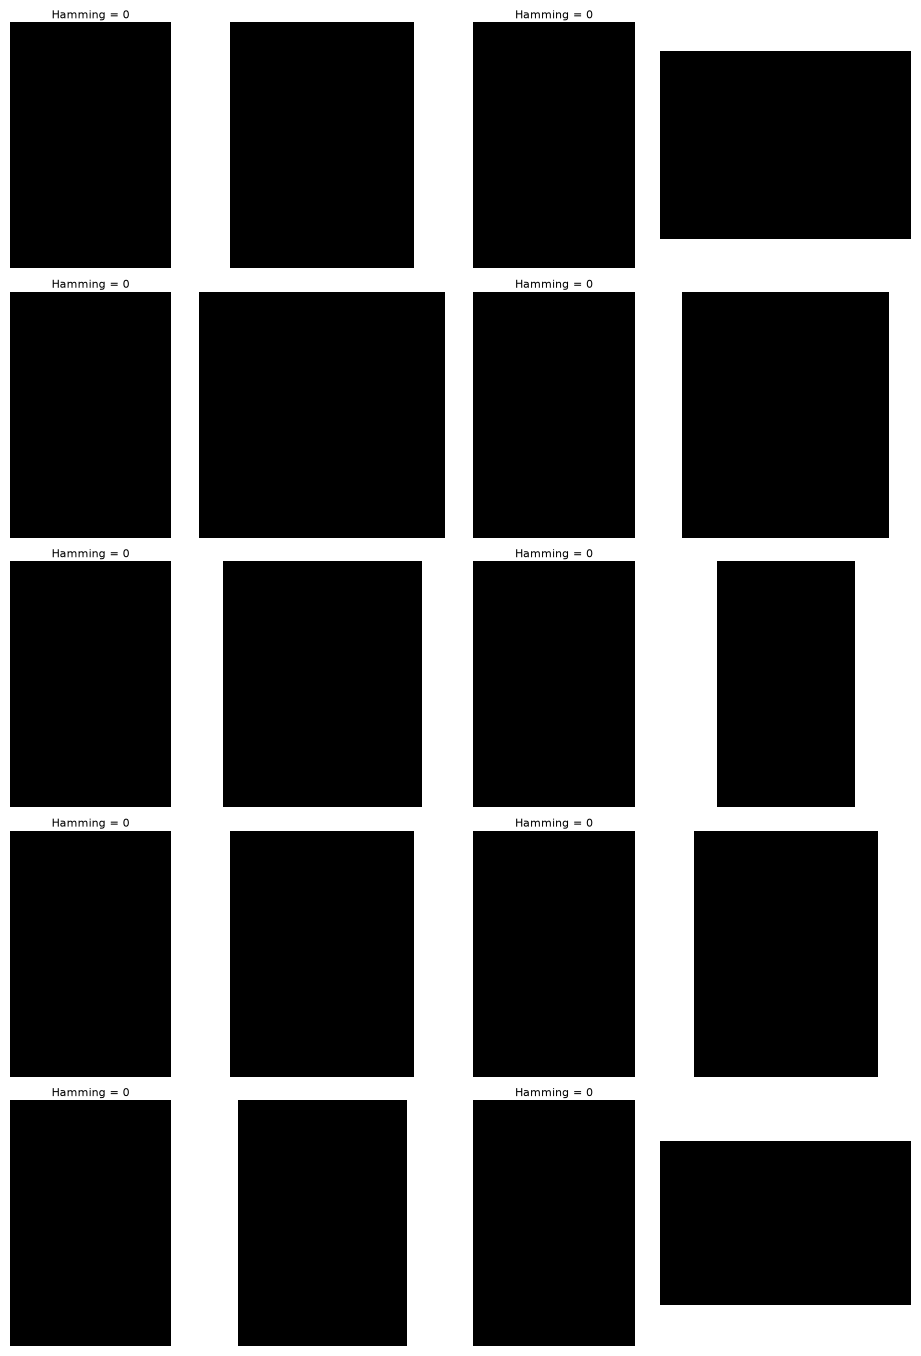

In [30]:
## Visual inspection of image pairs per source
sources= ["tiny_genimage", "ntire", "coco", "raise"]

for sc in sources:
    sample_mask = df["source"] == sc
    sample = df[sample_mask].reset_index(drop=True)
    pairs = near_duplicate_pairs(sample["phash"].tolist(), **dedup_cfg) 
      # Ensure dedup parameters are updated in subset_v1.config
    pairs_sorted = sorted(pairs, key=lambda t: t[2])  
      # Sorting via hamming distance in index 2 of the returned tuple
    path_pairs = [
        (RAW / str(sample.loc[a, "path"]), RAW / str(sample.loc[b, "path"]), d)
        for a, b, d in pairs_sorted
    ]
    if path_pairs:
        fig = viz.pair_grid(path_pairs, max_pairs= 10)
        fig.show()
    else:
        print(f"No near-duplicate pairs found in this sample at the current threshold for image source **{sc}**")

Genuine image duplicates as well as the suspicious pure-black image cluster of 29 images comes from `ntire` image source. These pure-black images can be dropped from the dataset.

In [ ]:
zero_phash = df["phash"].astype("string").str.lower().eq("0000000000000000")
n_zero_phash = int(zero_phash.sum())

if n_zero_phash:
    display(df.loc[zero_phash, ["path", "source", "phash"]].head(10))

df = df.loc[~zero_phash].reset_index(drop=True)

print(f"Dropped {n_zero_phash:,} images with pHash 0000000000000000")
print(f"Remaining: {len(df):,} images")

C:\Users\ProBook\AppData\Local\Temp\ipykernel_17164\3102512859.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


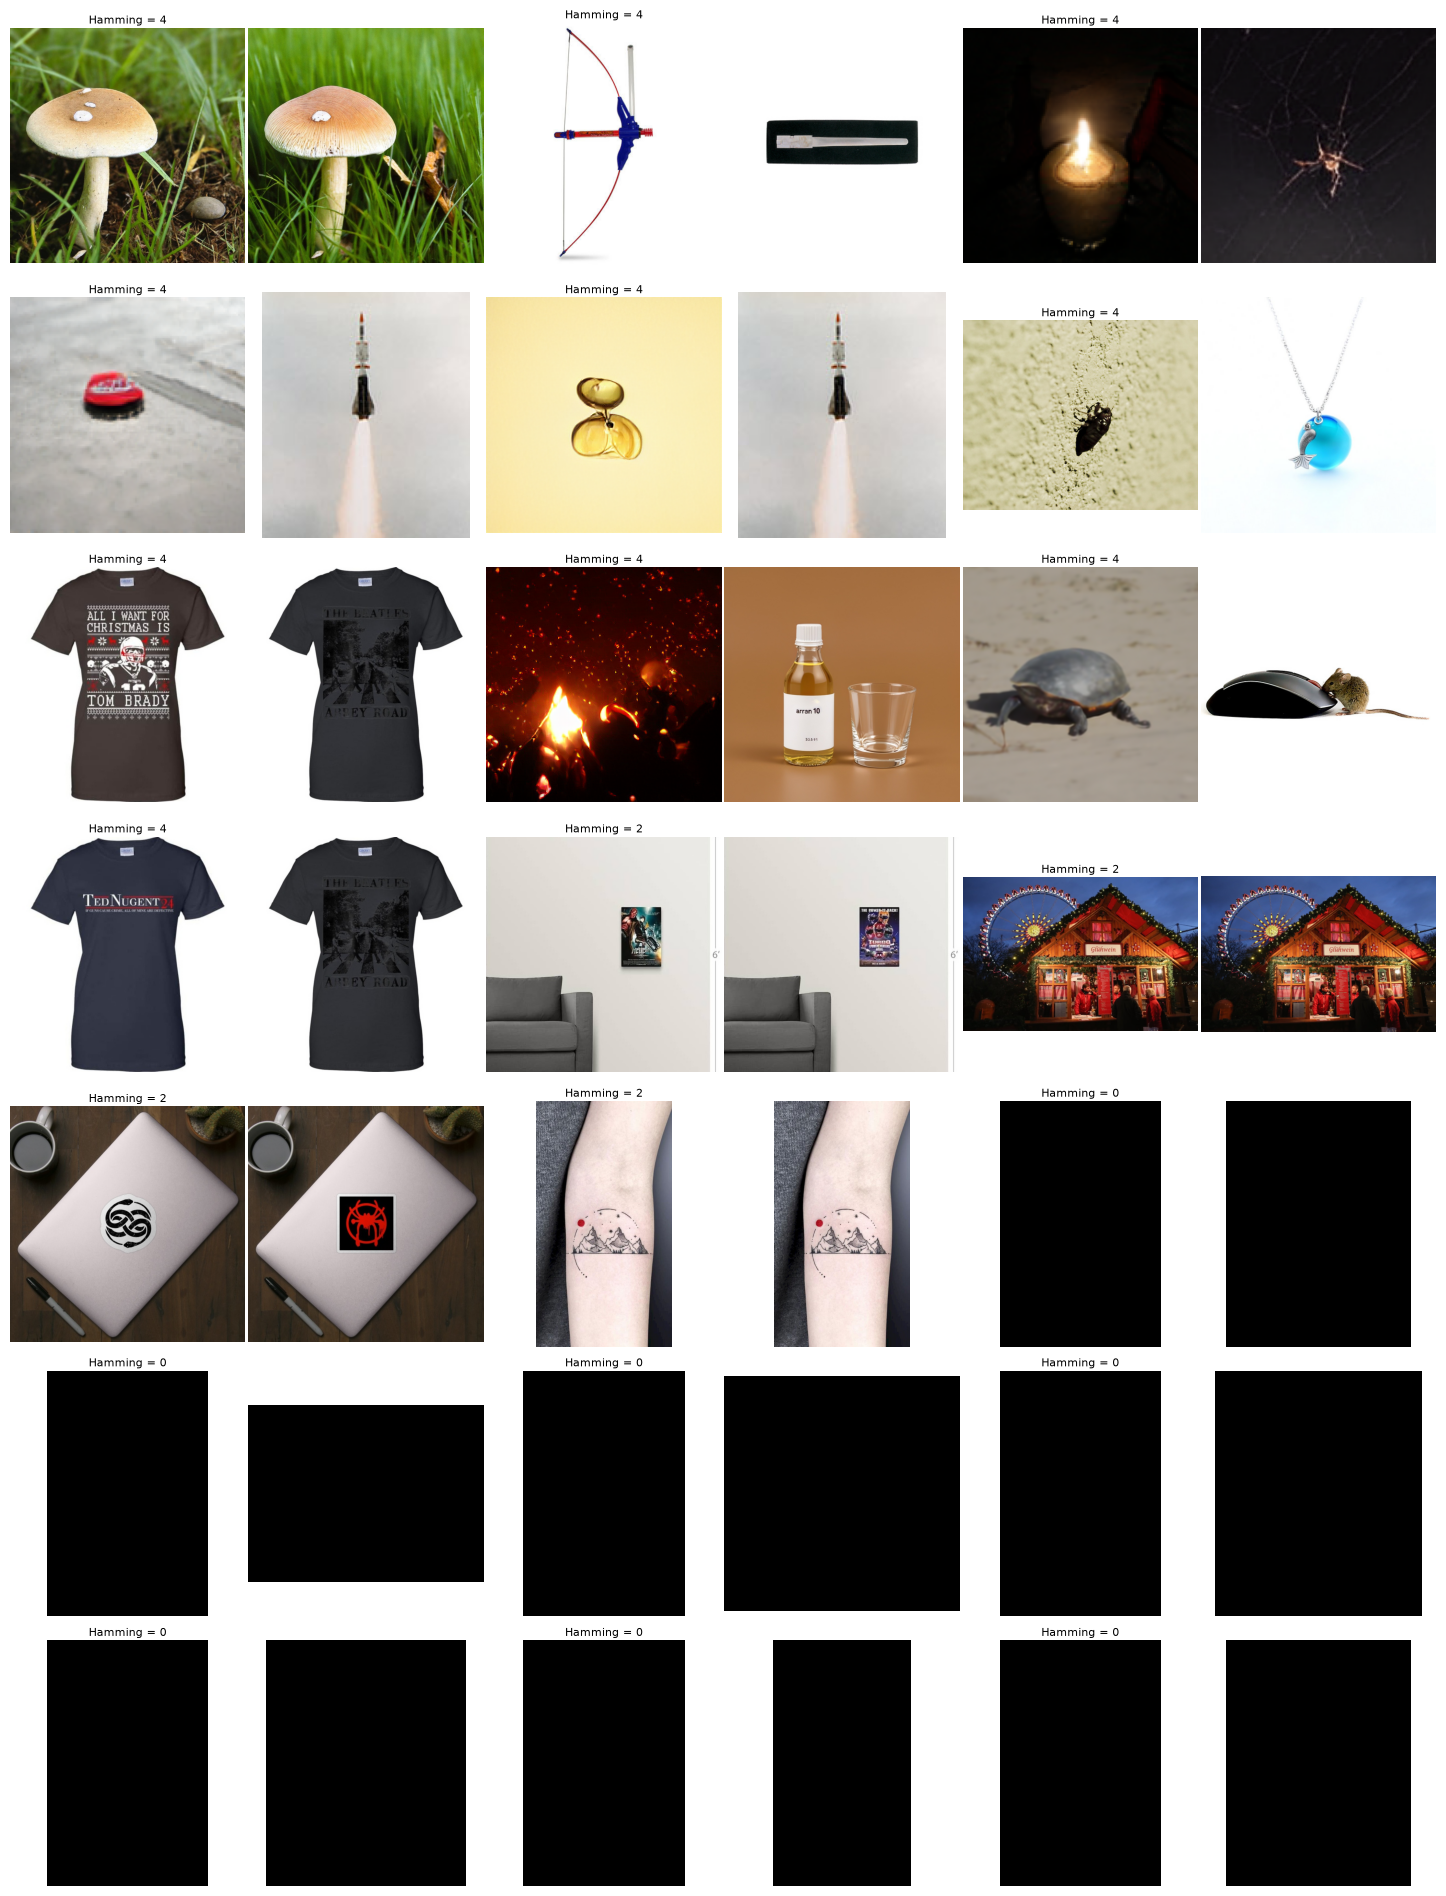

In [32]:
## Visual inspection of image pairs for the combined dataset
pairs = near_duplicate_pairs(df["phash"].tolist(), **dedup_cfg)
pairs_sorted = sorted(pairs, key=lambda t: t[2], reverse= True)
  # Images from the suspicious cluster have a hamming distance of 0 as shown above
  # Reverse sorting from highest hamming distance to lowest allows us to examine actual duplicates
path_pairs = [
    (RAW / str(df.loc[a, "path"]), RAW / str(df.loc[b, "path"]), d)
    for a, b, d in pairs_sorted
]
if path_pairs:
    fig = viz.pair_grid(path_pairs, max_pairs= 21, ncols= 3)
    fig.show()
else:
    print(f"No near-duplicate pairs found in this sample at the current threshold")

In [19]:
df["group_id"].value_counts()

group_id
40595    29
11262     3
45248     3
5137      2
5932      2
         ..
90248     1
90249     1
90250     1
90251     1
90252     1
Name: count, Length: 90253, dtype: int64